Compute daily returns

In [1]:
import pandas as pd

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
print(df_nav.head())
print(df_nav.info())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None


In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv('/content/nav_history_cleaned.csv')


df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date']).reset_index(drop=True)


df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()



def compute_annualized(group):
    returns = group['daily_return'].dropna()
    n = len(returns)
    if n == 0:
        return np.nan

    prod_returns = (1 + returns).prod()
    ann_return = (prod_returns ** (252 / n)) - 1
    return pd.Series({'n_days': n, 'annualized_return': ann_return})

summary = df.groupby('amfi_code').apply(compute_annualized).reset_index()
print(summary.head())

   amfi_code  n_days  annualized_return
0     100016  1149.0           0.025435
1     100025  1149.0           0.042987
2     100033  1149.0           0.289279
3     101206  1149.0           0.226265
4     101207  1149.0           0.076502


/tmp/ipykernel_5860/940259510.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('amfi_code').apply(compute_annualized).reset_index()


In [3]:
summary.to_csv('fund_annualized_returns.csv', index=False)
print("Saved to fund_annualized_returns.csv successfully.")

Saved to fund_annualized_returns.csv successfully.


Compute CAGR

In [4]:
import pandas as pd
import numpy as np


df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df_nav['date'] = pd.to_datetime(df_nav['date'])


latest_date = df_nav['date'].max()
print("Latest date in dataset:", latest_date)


target_1yr = latest_date - pd.DateOffset(years=1)
target_3yr = latest_date - pd.DateOffset(years=3)
target_5yr = latest_date - pd.DateOffset(years=5)

print(f"Target dates:\n1-Year: {target_1yr}\n3-Year: {target_3yr}\n5-Year: {target_5yr}")


def get_nav_at_date(group, target_date):

    idx = (group['date'] - target_date).abs().idxmin()
    closest_row = group.loc[idx]

    if abs((closest_row['date'] - target_date).days) > 7:
        return np.nan, np.nan
    return closest_row['nav'], closest_row['date']

results = []
funds = df_nav['amfi_code'].unique()

for amfi in funds:
    group = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').reset_index(drop=True)
    if group.empty:
        continue

    end_nav = group.iloc[-1]['nav']
    end_date = group.iloc[-1]['date']

    # 1 Yr
    nav_1y, date_1y = get_nav_at_date(group, target_1yr)
    # 3 Yr
    nav_3y, date_3y = get_nav_at_date(group, target_3yr)
    # 5 Yr
    nav_5y, date_5y = get_nav_at_date(group, target_5yr)

    cagr_1y = (end_nav / nav_1y) ** (1/1.0) - 1 if pd.notna(nav_1y) else np.nan
    cagr_3y = (end_nav / nav_3y) ** (1/3.0) - 1 if pd.notna(nav_3y) else np.nan
    cagr_5y = (end_nav / nav_5y) ** (1/5.0) - 1 if pd.notna(nav_5y) else np.nan


    name_row = df_master[df_master['amfi_code'] == amfi]
    scheme_name = name_row['scheme_name'].values[0] if not name_row.empty else "Unknown"

    results.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'Latest_Date': end_date.strftime('%Y-%m-%d'),
        'Latest_NAV': end_nav,
        '1Yr_CAGR': cagr_1y,
        '3Yr_CAGR': cagr_3y,
        '5Yr_CAGR': cagr_5y
    })

df_cagr = pd.DataFrame(results)
print(df_cagr[df_cagr['scheme_name'].str.contains('SBI Bluechip|HDFC Top 100', case=False, na=False)])

    amfi_code                                scheme_name
0      100016  HDFC Top 100 Fund - Regular Plan - Growth
19     119551  SBI Bluechip Fund - Regular Plan - Growth
20     119552   SBI Bluechip Fund - Direct Plan - Growth
32     125497   HDFC Top 100 Fund - Direct Plan - Growth
NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [6]:
import pandas as pd

latest_date = df_nav['date'].max()
target_1yr = latest_date - pd.DateOffset(years=1)
target_3yr = latest_date - pd.DateOffset(years=3)
target_5yr = latest_date - pd.DateOffset(years=5)

for amfi in [100016, 119551, 119552, 125497]:
    group = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').reset_index(drop=True)
    print(f"\n--- AMFI {amfi} ---")
    for label, target in [('1Yr', target_1yr), ('3Yr', target_3yr), ('5Yr', target_5yr)]:
        idx = (group['date'] - target).abs().idxmin()
        row = group.loc[idx]
        days_diff = (row['date'] - target).days
        print(f"{label}: Target={target.strftime('%Y-%m-%d')}, Closest={row['date'].strftime('%Y-%m-%d')}, NAV={row['nav']}, Days Diff={days_diff}")


--- AMFI 100016 ---
1Yr: Target=2025-05-29, Closest=2025-05-29, NAV=596.8877, Days Diff=0
3Yr: Target=2023-05-29, Closest=2023-05-29, NAV=561.5519, Days Diff=0
5Yr: Target=2021-05-29, Closest=2022-01-03, NAV=520.4608, Days Diff=219

--- AMFI 119551 ---
1Yr: Target=2025-05-29, Closest=2025-05-29, NAV=93.0716, Days Diff=0
3Yr: Target=2023-05-29, Closest=2023-05-29, NAV=67.2551, Days Diff=0
5Yr: Target=2021-05-29, Closest=2022-01-03, NAV=54.3856, Days Diff=219

--- AMFI 119552 ---
1Yr: Target=2025-05-29, Closest=2025-05-29, NAV=130.2974, Days Diff=0
3Yr: Target=2023-05-29, Closest=2023-05-29, NAV=87.6319, Days Diff=0
5Yr: Target=2021-05-29, Closest=2022-01-03, NAV=58.4174, Days Diff=219

--- AMFI 125497 ---
1Yr: Target=2025-05-29, Closest=2025-05-29, NAV=936.4319, Days Diff=0
3Yr: Target=2023-05-29, Closest=2023-05-29, NAV=725.3323, Days Diff=0
5Yr: Target=2021-05-29, Closest=2022-01-03, NAV=560.1443, Days Diff=219


In [8]:
results_exact_n = []

funds = df_nav['amfi_code'].unique()

for amfi in funds:
    group = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').reset_index(drop=True)
    if group.empty:
        continue

    end_row = group.iloc[-1]
    end_nav = end_row['nav']
    end_date = end_row['date']

    row_data = {
        'amfi_code': amfi,
        'scheme_name': df_master[df_master['amfi_code'] == amfi]['scheme_name'].values[0] if amfi in df_master['amfi_code'].values else "Unknown",
        'Latest_Date': end_date.strftime('%Y-%m-%d'),
        'Latest_NAV': end_nav
    }

    for label, target in [('1Yr', target_1yr), ('3Yr', target_3yr), ('5Yr', target_5yr)]:
        idx = (group['date'] - target).abs().idxmin()
        row = group.loc[idx]


        if abs((row['date'] - target).days) <= 7:
            n = (end_date - row['date']).days / 365.25
            cagr = (end_nav / row['nav']) ** (1 / n) - 1
            row_data[f'{label}_CAGR'] = cagr
            row_data[f'{label}_Start_Date'] = row['date'].strftime('%Y-%m-%d')
        else:
            row_data[f'{label}_CAGR'] = np.nan
            row_data[f'{label}_Start_Date'] = np.nan

    results_exact_n.append(row_data)

df_cagr_exact = pd.DataFrame(results_exact_n)
print(df_cagr_exact[df_cagr_exact['scheme_name'].str.contains('SBI Bluechip|HDFC Top 100', case=False, na=False)][['scheme_name', '1Yr_CAGR', '3Yr_CAGR', '5Yr_CAGR']])

                                  scheme_name  1Yr_CAGR  3Yr_CAGR  5Yr_CAGR
0   HDFC Top 100 Fund - Regular Plan - Growth -0.022258  0.012924       NaN
19  SBI Bluechip Fund - Regular Plan - Growth  0.604893  0.304486       NaN
20   SBI Bluechip Fund - Direct Plan - Growth  0.057101  0.162634       NaN
32   HDFC Top 100 Fund - Direct Plan - Growth  0.286976  0.184299       NaN


In [9]:
df_cagr_exact.to_csv('fund_cagr_periods.csv', index=False)
print("Saved fund_cagr_periods.csv successfully.")

Saved fund_cagr_periods.csv successfully.


Compute Sharpe Ratio

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/nav_history_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['amfi_code', 'date']).reset_index(drop=True)

df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

def calculate_sharpe(group):
    returns = group['daily_return'].dropna()
    n = len(returns)
    if n == 0:
        return pd.Series({'sharpe_ratio': np.nan})
    rp = ((1 + returns).prod() ** (252 / n)) - 1
    rf = 0.065
    std_rp = returns.std() * np.sqrt(252)
    sharpe = (rp - rf) / std_rp if std_rp > 0 else np.nan
    return pd.Series({'sharpe_ratio': sharpe})

sharpe_df = df.groupby('amfi_code').apply(calculate_sharpe).reset_index()
sharpe_df.to_csv('fund_sharpe_ratios.csv', index=False)
print(sharpe_df.head())

   amfi_code  sharpe_ratio
0     100016     -0.271960
1     100025     -0.563690
2     100033      1.184359
3     101206      1.106967
4     101207      0.044584


/tmp/ipykernel_5860/645363018.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sharpe_df = df.groupby('amfi_code').apply(calculate_sharpe).reset_index()


Compute Sortino Ratio

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/nav_history_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['amfi_code', 'date']).reset_index(drop=True)

df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

def calculate_sortino(group):
    returns = group['daily_return'].dropna()
    n = len(returns)
    if n == 0:
        return pd.Series({'sortino_ratio': np.nan})
    rp = ((1 + returns).prod() ** (252 / n)) - 1
    rf = 0.065
    negative_returns = returns[returns < 0]
    if len(negative_returns) <= 1:
        return pd.Series({'sortino_ratio': np.nan})
    downside_std = negative_returns.std() * np.sqrt(252)
    sortino = (rp - rf) / downside_std if downside_std > 0 else np.nan
    return pd.Series({'sortino_ratio': sortino})

sortino_df = df.groupby('amfi_code').apply(calculate_sortino).reset_index()
sortino_df.to_csv('sortino_values.csv', index=False)
print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.473761
1     100025      -0.936166
2     100033       1.980757
3     101206       1.939283
4     101207       0.075827


/tmp/ipykernel_5860/2660919570.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sortino_df = df.groupby('amfi_code').apply(calculate_sortino).reset_index()


Compute Alpha & Beta vs benchmark

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load data
df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_bench = pd.read_csv('/content/cleaned_10_benchmark_indices.csv')

print("Benchmark index names:")
print(df_bench['index_name'].unique())

# Filter for NIFTY100
df_nifty = df_bench[df_bench['index_name'] == 'NIFTY100'].copy()
df_nifty['date'] = pd.to_datetime(df_nifty['date'])
df_nifty = df_nifty.sort_values('date').reset_index(drop=True)
df_nifty['bench_return'] = df_nifty['close_value'].pct_change()

print("\nNifty 100 returns head:")
print(df_nifty.head())

Benchmark index names:
['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']

Nifty 100 returns head:
        date index_name  close_value  bench_return
0 2022-01-03   NIFTY100     17778.24           NaN
1 2022-01-04   NIFTY100     17537.52     -0.013540
2 2022-01-05   NIFTY100     17607.73      0.004003
3 2022-01-06   NIFTY100     17556.05     -0.002935
4 2022-01-07   NIFTY100     17664.02      0.006150


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_bench = pd.read_csv('/content/cleaned_10_benchmark_indices.csv')

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])

df_nifty = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date').reset_index(drop=True)
df_nifty['bench_return'] = df_nifty['close_value'].pct_change()

df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
df_nav['fund_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Merge fund returns with benchmark returns on date
df_merged = pd.merge(df_nav, df_nifty[['date', 'bench_return']], on='date', how='inner')

results = []
for amfi, group in df_merged.groupby('amfi_code'):
    clean_group = group.dropna(subset=['fund_return', 'bench_return'])
    if len(clean_group) < 10:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(clean_group['bench_return'], clean_group['fund_return'])
    alpha = intercept * 252
    beta = slope

    results.append({
        'amfi_code': amfi,
        'alpha': alpha,
        'beta': beta
    })

df_res = pd.DataFrame(results)
df_res.to_csv('alpha_beta_values.csv', index=False)
print(df_res.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


Compute Maximum Drawdown

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/nav_history_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

def calculate_max_drawdown(group):
    group = group.sort_values('date').reset_index(drop=True)
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1

    if drawdown.empty or drawdown.isna().all():
        return pd.Series({
            'max_drawdown': np.nan,
            'peak_date': np.nan,
            'trough_date': np.nan
        })

    trough_idx = drawdown.idxmin()
    max_dd = drawdown.loc[trough_idx]
    peak_idx = group.loc[:trough_idx, 'nav'].idxmax()

    return pd.Series({
        'max_drawdown': max_dd,
        'peak_date': group.loc[peak_idx, 'date'].strftime('%Y-%m-%d'),
        'trough_date': group.loc[trough_idx, 'date'].strftime('%Y-%m-%d')
    })

max_dd_df = df.groupby('amfi_code').apply(calculate_max_drawdown).reset_index()
max_dd_df.to_csv('max_drawdown.csv', index=False)
print(max_dd_df.head())

   amfi_code  max_drawdown   peak_date trough_date
0     100016     -0.247344  2022-03-30  2022-09-15
1     100025     -0.043083  2023-05-23  2023-07-28
2     100033     -0.162172  2022-03-11  2022-05-12
3     101206     -0.112916  2023-04-24  2023-07-05
4     101207     -0.354469  2024-11-21  2026-05-11


/tmp/ipykernel_5860/1871872597.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_dd_df = df.groupby('amfi_code').apply(calculate_max_drawdown).reset_index()


Build Fund Scorecard

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_bench = pd.read_csv('/content/cleaned_10_benchmark_indices.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])

latest_date = df_nav['date'].max()
target_3yr = latest_date - pd.DateOffset(years=3)

df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

df_nifty = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date').reset_index(drop=True)
df_nifty['bench_return'] = df_nifty['close_value'].pct_change()

df_merged = pd.merge(df_nav, df_nifty[['date', 'bench_return']], on='date', how='inner')

metrics = []
for amfi, group in df_merged.groupby('amfi_code'):
    group = group.sort_values('date').reset_index(drop=True)
    valid_returns = group['daily_return'].dropna()
    n = len(valid_returns)
    if n < 2:
        continue

    end_nav = group.iloc[-1]['nav']
    end_date = group.iloc[-1]['date']
    closest_3y_idx = (group['date'] - target_3yr).abs().idxmin()
    start_row_3y = group.loc[closest_3y_idx]

    if abs((start_row_3y['date'] - target_3yr).days) <= 7:
        n_years = (end_date - start_row_3y['date']).days / 365.25
        return_3yr = (end_nav / start_row_3y['nav']) ** (1 / n_years) - 1
    else:
        return_3yr = np.nan

    rp = ((1 + valid_returns).prod() ** (252 / n)) - 1
    std_rp = valid_returns.std() * np.sqrt(252)
    sharpe = (rp - 0.065) / std_rp if std_rp > 0 else np.nan

    clean_group = group.dropna(subset=['daily_return', 'bench_return'])
    if len(clean_group) >= 2:
        slope, intercept, _, _, _ = linregress(clean_group['bench_return'], clean_group['daily_return'])
        alpha = intercept * 252
    else:
        alpha = np.nan

    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    max_dd = drawdown.min() if not drawdown.empty else np.nan

    metrics.append({
        'amfi_code': amfi,
        'return_3yr': return_3yr,
        'sharpe': sharpe,
        'alpha': alpha,
        'max_dd': max_dd
    })

df_metrics = pd.DataFrame(metrics)
df_final = pd.merge(df_metrics, df_master[['amfi_code', 'scheme_name', 'expense_ratio_pct']], on='amfi_code', how='inner')

df_final['rank_return_3yr'] = df_final['return_3yr'].rank(pct=True)
df_final['rank_sharpe'] = df_final['sharpe'].rank(pct=True)
df_final['rank_alpha'] = df_final['alpha'].rank(pct=True)
df_final['rank_expense'] = df_final['expense_ratio_pct'].rank(pct=True, ascending=False)
df_final['rank_max_dd'] = df_final['max_dd'].rank(pct=True)

for col in ['rank_return_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_max_dd']:
    df_final[col] = df_final[col].fillna(0.5)

df_final['Score'] = (
    0.30 * df_final['rank_return_3yr'] +
    0.25 * df_final['rank_sharpe'] +
    0.20 * df_final['rank_alpha'] +
    0.15 * df_final['rank_expense'] +
    0.10 * df_final['rank_max_dd']
) * 100

df_final = df_final.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_final.to_csv('fund_scorecard.csv', index=False)
print(df_final[['scheme_name', 'Score']].head())

                                         scheme_name  Score
0      Mirae Asset Large Cap Fund - Regular - Growth  86.25
1           ICICI Pru Midcap Fund - Regular - Growth  82.25
2             Kotak Flexicap Fund - Regular - Growth  82.00
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  80.75
4          ICICI Pru Bluechip Fund - Direct - Growth  80.00


Benchmark Comparison Chart

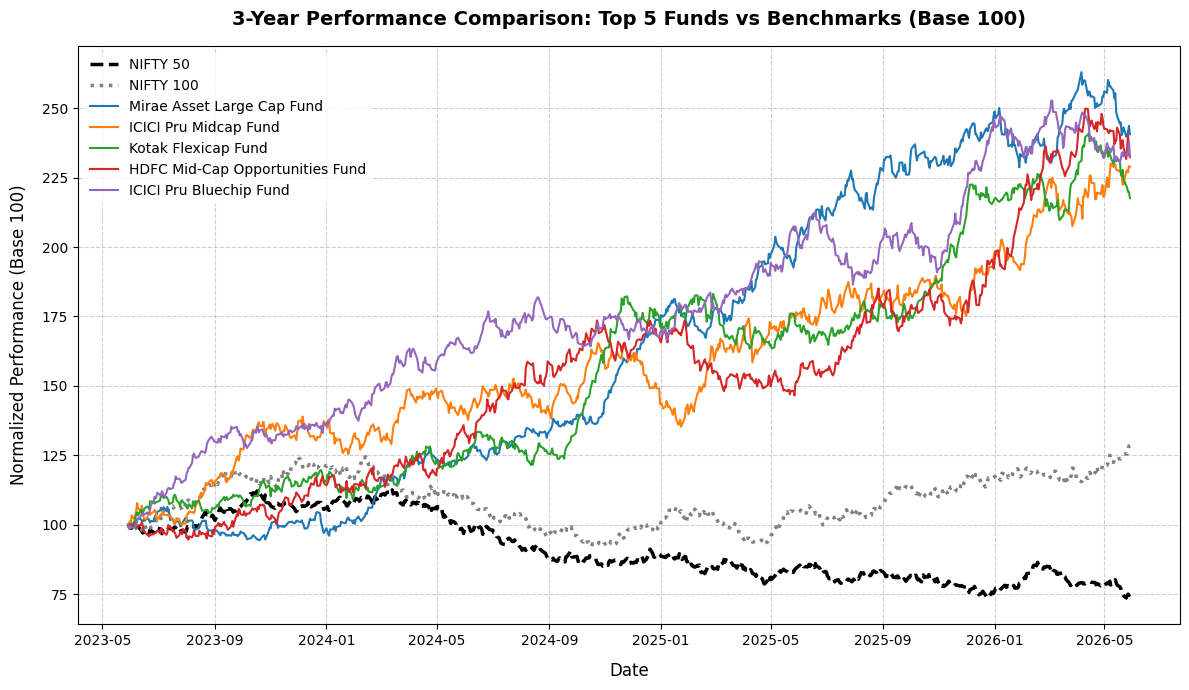

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_scorecard = pd.read_csv('/content/fund_scorecard.csv')
top_5_funds = df_scorecard.head(5)
top_5_amfi = top_5_funds['amfi_code'].tolist()


df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_bench = pd.read_csv('/content/cleaned_10_benchmark_indices.csv')

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])


latest_date = df_nav['date'].max()
start_date_3yr = latest_date - pd.DateOffset(years=3)


df_b = df_bench[df_bench['index_name'].isin(['NIFTY50', 'NIFTY100']) & (df_bench['date'] >= start_date_3yr)]
df_b_pivot = df_b.pivot(index='date', columns='index_name', values='close_value')

df_f = df_nav[df_nav['amfi_code'].isin(top_5_amfi) & (df_nav['date'] >= start_date_3yr)]
df_f_pivot = df_f.pivot(index='date', columns='amfi_code', values='nav')

df_merged = pd.merge(df_b_pivot, df_f_pivot, left_index=True, right_index=True, how='outer').sort_index()
df_merged = df_merged.ffill().dropna()


df_returns = df_merged.pct_change().dropna()


tracking_errors = []
for amfi in top_5_amfi:
    scheme_name = top_5_funds[top_5_funds['amfi_code'] == amfi]['scheme_name'].values[0]


    diff_n50 = df_returns[amfi] - df_returns['NIFTY50']
    te_n50 = diff_n50.std() * np.sqrt(252)


    diff_n100 = df_returns[amfi] - df_returns['NIFTY100']
    te_n100 = diff_n100.std() * np.sqrt(252)

    tracking_errors.append({
        'scheme_name': scheme_name,
        'TE_Nifty50': te_n50,
        'TE_Nifty100': te_n100
    })


df_norm = (df_merged / df_merged.iloc[0]) * 100


fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(df_norm.index, df_norm['NIFTY50'], label='NIFTY 50', color='black', linewidth=2.5, linestyle='--')
ax.plot(df_norm.index, df_norm['NIFTY100'], label='NIFTY 100', color='grey', linewidth=2.5, linestyle=':')

for amfi in top_5_amfi:
    name = top_5_funds[top_5_funds['amfi_code'] == amfi]['scheme_name'].values[0].split(' - ')[0]
    ax.plot(df_norm.index, df_norm[amfi], label=name, linewidth=1.5)

ax.set_title('3-Year Performance Comparison: Top 5 Funds vs Benchmarks (Base 100)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12, labelpad=10)
ax.set_ylabel('Normalized Performance (Base 100)', fontsize=12, labelpad=10)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('benchmark_comparison_3yr.png', dpi=300)